# 🌊 갯녹음 예측을 통한 바다숲 우선 조성 지역 선정 프로젝트

본 프로젝트는 **기후 변화로 인한 해양 사막화(갯녹음)** 문제를 데이터 분석으로 해결하기 위해 수행되었습니다.
머신러닝 기반의 예측 모델을 통해 미래 갯녹음 발생량을 추정하고, 이를 바탕으로 제한된 자원으로 최대 효과를 낼 수 있는 **바다숲 우선 조성 지역을 도출**하는 것을 목표로 합니다.

**주요 단계**
1. 📦 **라이브러리 및 데이터 로드:** 분석에 필요한 라이브러리 불러오기 및 데이터셋 준비
2. 🔍 **EDA (기초 탐색):** 데이터 구조 확인 및 주요 변수의 분포 탐색
3. 🧹 **데이터 전처리:** 결측치 처리, 파생변수 생성, 데이터 정제
4. 🤖 **모델링:** 다양한 머신러닝 회귀 모델로 갯녹음 비율 예측
5. 📊 **성능 평가:** 모델별 성능 비교 및 최종 모델 선정
6. 📁 **결과 저장:** 예측 결과를 기반으로 바다숲 우선 조성 지역 리스트 생성 및 저장


# 1️⃣ 라이브러리 Import 및 데이터 로드

- 분석에 필요한 라이브러리를 불러오고 데이터를 로드합니다.

In [62]:
# 한글 폰트 사용을 위해서 세팅
from matplotlib import font_manager, rc
font_path = "C:/Windows/Fonts/NGULIM.TTF"
font = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font)

In [647]:
import pandas as pd 
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error

from numpy import ndarray
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant
import time
import datetime
import itertools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import InputLayer
from sklearn.ensemble import AdaBoostRegressor
from keras.wrappers.scikit_learn import KerasRegressor

import tensorflow as tf
from keras.preprocessing.sequence import TimeseriesGenerator
from keras.models import Sequential
from keras.layers import LSTM, Dense


In [1196]:
df = pd.read_csv("C:/Users/손호진/Desktop/data_origin.csv", encoding = "CP949")
df2 = df.copy()
df2.index = df2['station']
#df2['영양염류'] = df2['아질산성질소[μg/L]'] + df2['용존무기질소[μg/L]'] + df2['질산성질소[μg/L]'] + df2['인산염인[μg/L]']
df2.drop(columns=['station', "수심(text)","화학적산소요구량[mg/L]", '용존무기질소[μg/L]', '질산성질소[μg/L]', '수소이온농도[무단위]'], inplace=True)
df2 = df2.iloc[:, 2:]
#df2.columns=['부유물질 농도', '수온', '염분', '용존산소', '화학적 산소요구량', '해역', '갯녹음 진행면적 비율', '갯녹음 면적', '영양염류']
#df2.drop(columns=['화학적 산소요구량', '갯녹음 면적'], inplace=True)
df2

,부유물질 농도[μg/L],수온[℃],아질산성질소[μg/L],염분[psu],용존산소[mg/L],인산염인[μg/L],해역,갯녹음 진행면적 비율
station,,,,,,,,
가로림연안1_연안,21.200000,13.880975,8.4385,31.128325,8.759373,19.08825,3,4.9
가로림연안2_연안,21.025000,13.756325,8.5890,31.171200,8.741297,18.93325,3,4.9
가로림연안3_연안,32.620825,13.510150,6.4785,31.277550,8.730298,16.69350,3,4.9
가막만1_환경관리,15.375000,16.777500,4.0750,32.392500,8.725000,11.52500,2,15.1
가막만2_환경관리,12.025000,16.597500,0.7500,32.502500,8.977500,2.37500,2,15.1
...,...,...,...,...,...,...,...,...
통영연안2_연안,7.300000,17.907500,3.2250,32.950000,8.745000,7.35000,2,15.9
통영연안4_연안,6.150000,18.290000,4.4500,33.140000,8.067500,8.32500,2,15.9
해남만1_연안,6.450000,16.392500,3.0000,30.855000,10.307500,1.40000,2,10.3


In [1201]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
 
def feature_engineering_XbyVIF(X_train):
    vif = pd.DataFrame()
    vif['VIF_Factor'] = [variance_inflation_factor(X_train.values, i)
                         for i in range(X_train.shape[1])]
    vif['Feature'] = X_train.columns
    return vif
vif = feature_engineering_XbyVIF(data_features)
print(vif)

   VIF_Factor        Feature
0    2.733840  부유물질 농도[μg/L]
1  251.708125          수온[℃]
2   18.798988   아질산성질소[μg/L]
3  364.035209        염분[psu]
4  236.188276     용존산소[mg/L]
5   25.464876     인산염인[μg/L]
6   19.042582             해역


In [1237]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(data_features)
scaled_features = scaler.transform(data_features)
scaled_features2 = pd.DataFrame(scaled_features)
scaled_features2.columns = data_features.columns
scaled_features2

,부유물질 농도[μg/L],수온[℃],아질산성질소[μg/L],염분[psu],용존산소[mg/L],인산염인[μg/L],해역
0,0.080150,0.067732,0.308813,0.822261,0.369018,0.456074,1.0
1,0.079363,0.044965,0.314781,0.825058,0.362459,0.452077,1.0
2,0.131504,0.000000,0.231090,0.831997,0.358467,0.394328,1.0
3,0.053958,0.596793,0.135779,0.904742,0.356545,0.261063,0.5
4,0.038895,0.563915,0.003926,0.911919,0.448176,0.025139,0.5
...,...,...,...,...,...,...,...
96,0.017649,0.803191,0.102072,0.941116,0.363803,0.153415,0.5
97,0.012478,0.873056,0.150649,0.953513,0.117941,0.178554,0.5
98,0.013827,0.526471,0.093150,0.804428,0.930827,0.000000,0.5
99,0.049349,0.833785,0.037633,0.900664,0.581540,0.059948,0.5


In [1241]:
import xgboost
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import explained_variance_score

from sklearn import ensemble
from sklearn.ensemble import RandomForestRegressor


X_train, X_test, y_train, y_test = train_test_split(scaled_features2, target ,test_size=0.05)

95 6


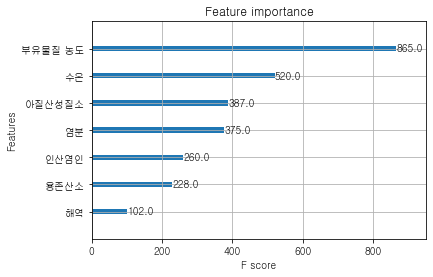

In [1497]:
## XGB
xgb_model = xgboost.XGBRegressor(n_estimators=100, learning_rate=0.05, gamma=0, subsample=0.75, colsample_bytree=1, max_depth=10)
print(len(X_train), len(X_test))
xgb_model.fit(X_train,y_train)

xgboost.plot_importance(xgb_model)

In [1247]:
df1997 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_1997_profile_chemical_unknown.csv", encoding = "euc-kr")
df1998 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_1998_profile_chemical_unknown.csv", encoding = "euc-kr")
df1999 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_1999_profile_chemical_unknown.csv", encoding = "euc-kr")
df2000 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2000_profile_chemical_unknown.csv", encoding = "euc-kr")
df2001 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2001_profile_chemical_unknown.csv", encoding = "euc-kr")
df2002 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2002_profile_chemical_unknown.csv", encoding = "euc-kr")
df2003 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2003_profile_chemical_unknown.csv", encoding = "euc-kr")
df2004 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2004_profile_chemical_unknown.csv", encoding = "euc-kr")
df2005 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2005_profile_chemical_unknown.csv", encoding = "euc-kr")
df2006 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2006_profile_chemical_unknown.csv", encoding = "euc-kr")
df2007 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2007_profile_chemical_unknown.csv", encoding = "euc-kr")
df2008 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2008_profile_chemical_unknown.csv", encoding = "euc-kr")
df2009 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2009_profile_chemical_unknown.csv", encoding = "euc-kr")
df2010 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2010_profile_chemical_unknown.csv", encoding = "euc-kr")
df2011 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2011_profile_chemical_unknown.csv", encoding = "euc-kr")
df2012 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2012_profile_chemical_unknown.csv", encoding = "euc-kr")
df2013 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2013_profile_chemical_unknown.csv", encoding = "euc-kr")
df2014 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2014_profile_chemical_unknown.csv", encoding = "euc-kr")
df2015 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2015_profile_chemical_unknown.csv", encoding = "euc-kr")
df2016 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2016_profile_chemical_unknown.csv", encoding = "euc-kr")
df2017 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2017_profile_chemical_unknown.csv", encoding = "euc-kr")
df2018 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2018_profile_chemical_unknown.csv", encoding = "euc-kr")
df2019 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2019_profile_chemical_unknown.csv", encoding = "euc-kr")
df2020 = pd.read_csv("C:/Users/손호진/Desktop/연도별/해양환경측정망_2020_profile_chemical_unknown.csv", encoding = "euc-kr")

# 2️⃣ EDA (기초 탐색)

- 데이터의 기본 정보와 통계량을 확인하고, 변수 간 분포와 관계를 시각화합니다.

In [16]:
# 물리적 원인
## 수온상승 -> 수온
## 담수 유입 -> 염분
## 개발 -> 부유물질농도

# 화학적 원인
## 염도 변화 -> 염분
## 영양염류 -> 질소 + 인 + ... 인 영양염류
## 오염물질 -> 용존산소

# +로 해역..

In [1197]:
df2.corr()['갯녹음 진행면적 비율'].abs().sort_values(ascending=False)

갯녹음 진행면적 비율      1.000000
해역               0.841989
인산염인[μg/L]       0.424716
염분[psu]          0.398090
아질산성질소[μg/L]     0.337069
수온[℃]            0.275232
용존산소[mg/L]       0.260059
부유물질 농도[μg/L]    0.255815
Name: 갯녹음 진행면적 비율, dtype: float64

In [1198]:
df2.corr()['갯녹음 진행면적 비율'].abs().sort_values(ascending=False)

갯녹음 진행면적 비율      1.000000
해역               0.841989
인산염인[μg/L]       0.424716
염분[psu]          0.398090
아질산성질소[μg/L]     0.337069
수온[℃]            0.275232
용존산소[mg/L]       0.260059
부유물질 농도[μg/L]    0.255815
Name: 갯녹음 진행면적 비율, dtype: float64

In [1200]:
# 다중 선형회귀분석
# for b0, 상수항 추가
#data_features2 = sm.add_constant(data_features, has_constant = "add")

# OLS 검정
multi_model = sm.OLS(target, data_features)
fitted_multi_model = multi_model.fit()
fitted_multi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            갯녹음 진행면적 비율   R-squared (uncentered):                   0.875
Model:                            OLS   Adj. R-squared (uncentered):              0.865
Method:                 Least Squares   F-statistic:                              93.78
Date:                Sun, 21 Aug 2022   Prob (F-statistic):                    1.42e-39
Time:                        06:39:16   Log-Likelihood:                         -373.52
No. Observations:                 101   AIC:                                      761.0
Df Residuals:                      94   BIC:                                      779.3
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
부유물질 농도[μg/L]     0.0944      0.059      1.609      0.111      -0.022       0.211
수온[℃]            -1.7350      0.948     -1.831      0.070      -3.616       0.147
아질산성질소[μg/L]      0.9445      0.637      1.484      0.141      -0.320       2.209
염분[psu]           1.3010      0.598      2.176      0.032       0.114       2.488
용존산소[mg/L]        5.9981      1.783      3.364      0.001       2.458       9.538
인산염인[μg/L]       -0.1048      0.415     -0.252      0.801      -0.930       0.720
해역              -25.3265      2.102    -12.049      0.000     -29.500     -21.153
==============================================================================
Omnibus:                        0.006   Durbin-Watson:                   0.918
Prob(Omnibus):                  0.997   Jarque-Bera (JB):                0.110
Skew:                          -0.011   Prob(JB):                        0.947
Kurtosis:                       2.840   Cond. No.                         108.
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [1238]:
vif2 = feature_engineering_XbyVIF(scaled_features2)
print(vif2)

   VIF_Factor        Feature
0    2.344717  부유물질 농도[μg/L]
1   14.072971          수온[℃]
2   15.227823   아질산성질소[μg/L]
3   23.013063        염분[psu]
4    5.632263     용존산소[mg/L]
5   23.108969     인산염인[μg/L]
6    5.986889             해역


In [1240]:
scaled_features2.columns=['부유물질 농도','수온','아질산성질소','염분','용존산소','인산염인','해역']

In [1485]:
X_test

,부유물질 농도,수온,아질산성질소,염분,용존산소,인산염인,해역
40,0.052609,0.552499,0.161554,0.883700,0.288502,0.179199,0.5
27,0.161593,0.392851,0.849410,0.102365,0.241601,0.871312,1.0
55,0.001461,0.387654,0.048538,0.992660,0.297574,0.118606,0.0
10,0.004946,0.749765,0.104055,0.964768,0.547065,0.176620,0.5
89,0.029789,0.703188,0.145692,0.939322,0.165117,0.186289,0.5
67,0.009780,0.504096,0.283494,0.942910,0.228624,0.358398,0.5


In [1246]:
## 시계열
def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true-y_pred))

def MSE(y_true, y_pred):
    return np.mean(np.square(y_true-y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true-y_pred)))

In [1252]:
common_columns = set(df1997.columns) & set(df1998.columns) & set(df1999.columns) & set(df2000.columns) & set(df2001.columns) & set(df2002.columns) & set(df2003.columns) & set(df2004.columns) & set(df2005.columns) & set(df2006.columns) & set(df2007.columns) & set(df2008.columns) & set(df2009.columns) & set(df2010.columns) &  set(df2011.columns) & set(df2012.columns) & set(df2013.columns) & set(df2014.columns) & set(df2015.columns) & set(df2016.columns) & set(df2017.columns) & set(df2018.columns) & set(df2019.columns) & set(df2020.columns)

In [1253]:
common_columns

{'Latitude [degrees_north]',
 'Longitude [degrees_east]',
 'amn_qc',
 'bot.depth[m]',
 'cheoxydem_qc',
 'chla_qc',
 'disinon_qc',
 'disoxy_qc',
 'hydioncon_qc',
 'natnit_qc',
 'nitnit_qc',
 'po4p_qc',
 'project_name',
 'reasil_qc',
 'sal_qc',
 'station',
 'sussed_qc',
 'tn_qc',
 'totp_qc',
 'tr_qc',
 'wtrtmp_qc',
 'yyyy-mm-dd hh:mm:ss',
 '규산염[μg/L]',
 '부유물질 농도[μg/L]',
 '수소이온농도[무단위]',
 '수심(m)',
 '수심(text)',
 '수온[℃]',
 '아질산성질소[μg/L]',
 '암모니아성 질소[μg/L]',
 '염분[psu]',
 '용존무기질소[μg/L]',
 '용존산소[mg/L]',
 '인산염인[μg/L]',
 '질산성질소[μg/L]',
 '총인[μg/L]',
 '총질소[μg/L]',
 '클로로필-a[μg/L]',
 '투명도[m]',
 '화학적산소요구량[mg/L]'}

In [1254]:
len(common_columns)

40

In [1255]:
common_columns = ['Latitude [degrees_north]','Longitude [degrees_east]','project_name','station','yyyy-mm-dd hh:mm:ss', '부유물질 농도[μg/L]','수소이온농도[무단위]', '수심(text)','수온[℃]','아질산성질소[μg/L]', '염분[psu]', '용존무기질소[μg/L]', '용존산소[mg/L]', '인산염인[μg/L]', '질산성질소[μg/L]','화학적산소요구량[mg/L]']

In [1256]:
len(common_columns)

16

In [1257]:
print(df1997.shape)
print(df1998.shape)
print(df1999.shape)
print(df2000.shape)
print(df2001.shape)
print(df2002.shape)
print(df2003.shape)
print('\n')
print(df2004.shape)
print(df2005.shape)
print(df2006.shape)
print(df2007.shape)
print(df2008.shape)
print(df2009.shape)
print(df2010.shape)
print(df2011.shape)
print(df2012.shape)
print(df2013.shape)
print(df2014.shape)
print(df2015.shape)
print(df2016.shape)
print(df2017.shape)
print(df2018.shape)
print(df2019.shape)
print(df2020.shape)

(970, 42)
(957, 42)
(971, 42)
(1033, 42)
(1056, 42)
(1056, 42)
(1056, 42)


(1178, 42)
(1167, 42)
(1164, 40)
(1183, 40)
(1115, 40)
(1252, 42)
(1193, 42)
(1281, 40)
(1200, 40)
(1441, 40)
(1562, 40)
(1567, 40)
(1552, 40)
(1568, 40)
(1600, 40)
(1600, 40)
(1615, 40)


In [1258]:
df1997 = df1997[common_columns]
df1998 = df1998[common_columns]
df1999 = df1999[common_columns]
df2000 = df2000[common_columns]
df2001 = df2001[common_columns]
df2002 = df2002[common_columns]
df2003 = df2003[common_columns]
df2004 = df2004[common_columns]
df2005 = df2005[common_columns]
df2006 = df2006[common_columns]
df2007 = df2007[common_columns]
df2008 = df2008[common_columns]
df2009 = df2009[common_columns]
df2010 = df2010[common_columns]
df2011 = df2011[common_columns]
df2012 = df2012[common_columns]
df2013 = df2013[common_columns]
df2014 = df2014[common_columns]
df2015 = df2015[common_columns]
df2016 = df2016[common_columns]
df2017 = df2017[common_columns]
df2018 = df2018[common_columns]
df2019 = df2019[common_columns]
df2020 = df2020[common_columns]

In [1259]:
print(df2004.shape)
print(df2005.shape)
print(df2006.shape)
print(df2007.shape)
print(df2008.shape)
print(df2009.shape)
print(df2010.shape)
print(df2011.shape)
print(df2012.shape)
print(df2013.shape)
print(df2014.shape)
print(df2015.shape)
print(df2016.shape)
print(df2017.shape)
print(df2018.shape)
print(df2019.shape)
print(df2020.shape)

(1178, 16)
(1167, 16)
(1164, 16)
(1183, 16)
(1115, 16)
(1252, 16)
(1193, 16)
(1281, 16)
(1200, 16)
(1441, 16)
(1562, 16)
(1567, 16)
(1552, 16)
(1568, 16)
(1600, 16)
(1600, 16)
(1615, 16)


In [1260]:
print('1997', df1997.isnull().sum())
print('\n')
print('1998', df1998.isnull().sum())
print('\n')
print('1999', df1999.isnull().sum())
print('\n')
print('2000', df2000.isnull().sum())
print('\n')
print('2001', df2001.isnull().sum())
print('\n')
print('2002', df2002.isnull().sum())
print('\n')
print('2003', df2003.isnull().sum())
print('\n')
print('2004', df2004.isnull().sum())
print('\n')
print('2005', df2005.isnull().sum())
print('\n')
print('2006', df2006.isnull().sum())
print('\n')
print('2007', df2007.isnull().sum())
print('\n')
print('2008', df2008.isnull().sum())
print('\n')
print('2009', df2009.isnull().sum())
print('\n')
print('2010', df2010.isnull().sum())
print('\n')
print('2011', df2011.isnull().sum())
print('\n')
print('2012', df2012.isnull().sum())
print('\n')
print('2013', df2013.isnull().sum())
print('\n')
print('2014', df2014.isnull().sum())
print('\n')
print('2015', df2015.isnull().sum())
print('\n')
print('2016', df2016.isnull().sum())
print('\n')
print('2017', df2017.isnull().sum())
print('\n')
print('2018', df2018.isnull().sum())
print('\n')
print('2019', df2019.isnull().sum())
print('\n')
print('2020', df2020.isnull().sum())

1997 Latitude [degrees_north]    0
Longitude [degrees_east]    0
project_name                0
station                     0
yyyy-mm-dd hh:mm:ss         0
부유물질 농도[μg/L]               0
수소이온농도[무단위]                 0
수심(text)                    0
수온[℃]                       0
아질산성질소[μg/L]                0
염분[psu]                     0
용존무기질소[μg/L]                0
용존산소[mg/L]                  0
인산염인[μg/L]                  0
질산성질소[μg/L]                 0
화학적산소요구량[mg/L]              0
dtype: int64


1998 Latitude [degrees_north]    0
Longitude [degrees_east]    0
project_name                0
station                     0
yyyy-mm-dd hh:mm:ss         0
부유물질 농도[μg/L]               0
수소이온농도[무단위]                 0
수심(text)                    0
수온[℃]                       0
아질산성질소[μg/L]                0
염분[psu]                     0
용존무기질소[μg/L]                0
용존산소[mg/L]                  0
인산염인[μg/L]                  0
질산성질소[μg/L]                 0
화학적산소요구량[mg/L]              0
dtype: int64




In [1262]:
df_count = df_raw.groupby(['station']).count()
df_count
#df_count[df_count['수심(text)'] > 95]

,Latitude [degrees_north],Longitude [degrees_east],project_name,yyyy-mm-dd hh:mm:ss,부유물질 농도[μg/L],수소이온농도[무단위],수심(text),수온[℃],아질산성질소[μg/L],염분[psu],용존무기질소[μg/L],용존산소[mg/L],인산염인[μg/L],질산성질소[μg/L],화학적산소요구량[mg/L]
station,,,,,,,,,,,,,,,
가로림연안1_연안,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
가로림연안2_연안,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
가로림연안3_연안,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96
가로림연안4_연안,28,28,28,28,28,28,28,28,28,28,28,28,28,28,28
가로림연안5_연안,28,28,28,28,28,28,28,28,28,28,28,28,28,28,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
행암만3_환경관리,28,28,28,28,28,28,28,28,28,28,28,28,28,28,28
행암만4_환경관리,28,28,28,28,28,28,28,28,28,28,28,28,28,28,28
후포연안1_연안,96,96,96,96,96,96,96,96,96,96,96,96,96,96,96


In [1263]:
station_list = df2.index
station_list

Index(['가로림연안1_연안', '가로림연안2_연안', '가로림연안3_연안', '가막만1_환경관리', '가막만2_환경관리',
       '가막만3_환경관리', '감포연안1_연안', '강구연안1_연안', '강릉연안1_연안', '강릉연안2_연안',
       ...
       '축산연안1_연안', '태안연안1_연안', '태안연안2_연안', '태안연안3_연안', '통영연안1_연안', '통영연안2_연안',
       '통영연안4_연안', '해남만1_연안', '행암만1_환경관리', '후포연안1_연안'],
      dtype='object', name='station', length=101)

In [1408]:
for k in range(102):
    print(main[k][main[k]['용존산소[mg/L]'].isna()])

Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 

Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성질소[μg/L], 염분[psu], 용존무기질소[μg/L], 용존산소[mg/L], 인산염인[μg/L], 질산성질소[μg/L], 화학적산소요구량[mg/L], Date]
Index: []
Empty DataFrame
Columns: [Latitude [degrees_north], Longitude [degrees_east], project_name, station, yyyy-mm-dd hh:mm:ss, 부유물질 농도[μg/L], 수소이온농도[무단위], 수심(text), 수온[℃], 아질산성

In [1267]:
main = []
future = []

In [1319]:
for i in range(len(station_list)):
    main.append(df_raw[df_raw['station'] == station_list[i]])

In [1318]:
col = ['부유물질 농도[μg/L]', '수온[℃]', '아질산성질소[μg/L]', '염분[psu]', '용존산소[mg/L]', '인산염인[μg/L]']

In [1308]:
col

['부유물질 농도[μg/L]',
 '수온[℃]',
 '아질산성질소[μg/L]',
 '염분[psu]',
 '용존산소[mg/L]',
 '인산염인[μg/L]']

In [1310]:
len(station_list)

101

In [1537]:
future = []

for j in range(len(station_list)):
#for j in range(2, 4):
    f_data = []
    f_data.append(station_list[j])
    for i in range(0, len(col)):
        dp = main[j].reset_index()
        dp = dp[col]

        dp = pd.DataFrame(main[j])
        dp['Date'] = pd.date_range('1900-01-01', periods=96)
    
        close_data = dp[col[i]].values
        close_data = close_data.reshape((-1,1))

        split_percent = 0.9
        split = int(split_percent*len(close_data))

        close_train = close_data[:split]
        close_test = close_data[split:]

        date_train = dp['Date'][:split]
        date_test = dp['Date'][split:]
    
        look_back = 8

        train_generator = TimeseriesGenerator(close_train, close_train, length=look_back, batch_size=20)     
        test_generator = TimeseriesGenerator(close_test, close_test, length=look_back, batch_size=1)
    
    
        model = Sequential()
        model.add(LSTM(10, activation='relu',input_shape=(look_back,1)))
        model.add(Dense(2))
        model.add(Dense(2))
        model.compile(optimizer='adam', loss='mse')

        num_epochs = 100
        model.fit_generator(train_generator, epochs=num_epochs, verbose=1)

        close_data = close_data.reshape((-1))

        def predict(num_prediction, model):
            prediction_list = close_data[-look_back:]
    
            for _ in range(num_prediction):
                x = prediction_list[-look_back:]
                x = x.reshape((1, look_back, 1))
                out = model.predict(x)[0][0]
                prediction_list = np.append(prediction_list, out)
            prediction_list = prediction_list[look_back-1:]
        
            return prediction_list
    
        def predict_dates(num_prediction):
            last_date = dp['Date'].values[-1]
            prediction_dates = pd.date_range(last_date, periods=num_prediction+1).tolist()
            return prediction_dates

        num_prediction = 4
        forecast = predict(num_prediction, model)
        forecast_dates = predict_dates(num_prediction)
    
        f_data.append(forecast[1:].mean())
        print(forecast[1:])
        print(col[i], f_data)
    future.append(f_data)

Epoch 1/100


<ipython-input-1537-0f4c7e9004e2>:39: UserWarning:

`Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.



4/4 [==============================] - 1s 5ms/step - loss: 535.3522
Epoch 2/100
4/4 [==============================] - 0s 6ms/step - loss: 533.0161
Epoch 3/100
4/4 [==============================] - 0s 6ms/step - loss: 530.3907
Epoch 4/100
4/4 [==============================] - 0s 6ms/step - loss: 527.3303
Epoch 5/100
4/4 [==============================] - 0s 6ms/step - loss: 523.9806
Epoch 6/100
4/4 [==============================] - 0s 6ms/step - loss: 520.0264
Epoch 7/100
4/4 [==============================] - 0s 5ms/step - loss: 515.7181
Epoch 8/100
4/4 [==============================] - 0s 5ms/step - loss: 510.5370
Epoch 9/100
4/4 [==============================] - 0s 5ms/step - loss: 503.9759
Epoch 10/100
4/4 [==============================] - 0s 6ms/step - loss: 496.7776
Epoch 11/100
4/4 [==============================] - 0s 6ms/step - loss: 487.3909
Epoch 12/100
4/4 [==============================] - 0s 6ms/step - loss: 475.8437
Epoch 13/100
4/4 [==============================]

1/1 [==============================] - 0s 20ms/step
[26.62955856 25.38959312 28.36015701 30.25590515]
부유물질 농도[μg/L] ['가로림연안1_연안', 27.658803462982178]
Epoch 1/100
4/4 [==============================] - 1s 4ms/step - loss: 216.2665
Epoch 2/100
4/4 [==============================] - 0s 4ms/step - loss: 213.8588
Epoch 3/100
4/4 [==============================] - 0s 4ms/step - loss: 211.4265
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 208.8858
Epoch 5/100
4/4 [==============================] - 0s 5ms/step - loss: 206.0552
Epoch 6/100
4/4 [==============================] - 0s 5ms/step - loss: 203.0509
Epoch 7/100
4/4 [==============================] - 0s 5ms/step - loss: 199.4321
Epoch 8/100
4/4 [==============================] - 0s 5ms/step - loss: 195.0024
Epoch 9/100
4/4 [==============================] - 0s 6ms/step - loss: 189.6319
Epoch 10/100
4/4 [==============================] - 0s 5ms/step - loss: 182.2576
Epoch 11/100
4/4 [==============================]

1/1 [==============================] - 0s 21ms/step
[ 3.78775024 11.45715237 24.97219658 16.78006935]
수온[℃] ['가로림연안1_연안', 27.658803462982178, 14.249292135238647]
Epoch 1/100
4/4 [==============================] - 1s 4ms/step - loss: 66.4865
Epoch 2/100
4/4 [==============================] - 0s 4ms/step - loss: 65.6454
Epoch 3/100
4/4 [==============================] - 0s 5ms/step - loss: 64.7247
Epoch 4/100
4/4 [==============================] - 0s 5ms/step - loss: 63.9551
Epoch 5/100
4/4 [==============================] - 0s 5ms/step - loss: 63.3696
Epoch 6/100
4/4 [==============================] - 0s 5ms/step - loss: 62.8354
Epoch 7/100
4/4 [==============================] - 0s 5ms/step - loss: 62.3825
Epoch 8/100
4/4 [==============================] - 0s 5ms/step - loss: 61.8934
Epoch 9/100
4/4 [==============================] - 0s 5ms/step - loss: 61.3558
Epoch 10/100
4/4 [==============================] - 0s 6ms/step - loss: 60.7856
Epoch 11/100
4/4 [=============================

...

4/4 [==============================] - 0s 5ms/step - loss: 5.1026
Epoch 53/100
4/4 [==============================] - 0s 6ms/step - loss: 5.0172
Epoch 54/100
4/4 [==============================] - 0s 5ms/step - loss: 4.9505
Epoch 55/100
4/4 [==============================] - 0s 6ms/step - loss: 4.8577
Epoch 56/100
4/4 [==============================] - 0s 5ms/step - loss: 4.7739
Epoch 57/100
4/4 [==============================] - 0s 5ms/step - loss: 4.6983
Epoch 58/100
4/4 [==============================] - 0s 6ms/step - loss: 4.5969
Epoch 59/100
4/4 [==============================] - 0s 5ms/step - loss: 4.4998
Epoch 60/100
4/4 [==============================] - 0s 6ms/step - loss: 4.3896
Epoch 61/100
4/4 [==============================] - 0s 5ms/step - loss: 4.2648
Epoch 62/100
4/4 [==============================] - 0s 6ms/step - loss: 4.1385
Epoch 63/100
4/4 [==============================] - 0s 7ms/step - loss: 4.0560
Epoch 64/100
4/4 [==============================] - 0s 5ms/step -

4/4 [==============================] - 0s 5ms/step - loss: 9.7924
Epoch 52/100
4/4 [==============================] - 0s 6ms/step - loss: 9.6374
Epoch 53/100
4/4 [==============================] - 0s 6ms/step - loss: 9.5449
Epoch 54/100
4/4 [==============================] - 0s 5ms/step - loss: 9.4359
Epoch 55/100
4/4 [==============================] - 0s 5ms/step - loss: 9.3821
Epoch 56/100
4/4 [==============================] - 0s 5ms/step - loss: 9.2608
Epoch 57/100
4/4 [==============================] - 0s 5ms/step - loss: 9.1474
Epoch 58/100
4/4 [==============================] - 0s 5ms/step - loss: 9.0375
Epoch 59/100
4/4 [==============================] - 0s 5ms/step - loss: 8.9303
Epoch 60/100
4/4 [==============================] - 0s 5ms/step - loss: 8.8559
Epoch 61/100
4/4 [==============================] - 0s 5ms/step - loss: 8.7011
Epoch 62/100
4/4 [==============================] - 0s 5ms/step - loss: 8.5986
Epoch 63/100
4/4 [==============================] - 0s 5ms/step -

4/4 [==============================] - 0s 5ms/step - loss: 0.4958
Epoch 50/100
4/4 [==============================] - 0s 6ms/step - loss: 0.4934
Epoch 51/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4905
Epoch 52/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4907
Epoch 53/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4889
Epoch 54/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4955
Epoch 55/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4895
Epoch 56/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4975
Epoch 57/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4895
Epoch 58/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4893
Epoch 59/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4980
Epoch 60/100
4/4 [==============================] - 0s 5ms/step - loss: 0.4947
Epoch 61/100
4/4 [==============================] - 0s 5ms/step -

4/4 [==============================] - 0s 5ms/step - loss: 0.7877
Epoch 49/100
4/4 [==============================] - 0s 6ms/step - loss: 0.7941
Epoch 50/100
4/4 [==============================] - 0s 6ms/step - loss: 0.7836
Epoch 51/100
4/4 [==============================] - 0s 7ms/step - loss: 0.7806
Epoch 52/100
4/4 [==============================] - 0s 6ms/step - loss: 0.7948
Epoch 53/100
4/4 [==============================] - 0s 6ms/step - loss: 0.7891
Epoch 54/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7799
Epoch 55/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7899
Epoch 56/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7839
Epoch 57/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7866
Epoch 58/100
4/4 [==============================] - 0s 5ms/step - loss: 0.7834
Epoch 59/100
4/4 [==============================] - 0s 6ms/step - loss: 0.7749
Epoch 60/100
4/4 [==============================] - 0s 5ms/step -

4/4 [==============================] - 0s 5ms/step - loss: 336.6600
Epoch 47/100
4/4 [==============================] - 0s 5ms/step - loss: 333.7193
Epoch 48/100
4/4 [==============================] - 0s 5ms/step - loss: 329.1257
Epoch 49/100
4/4 [==============================] - 0s 5ms/step - loss: 325.6740
Epoch 50/100
4/4 [==============================] - 0s 6ms/step - loss: 323.2293
Epoch 51/100
4/4 [==============================] - 0s 5ms/step - loss: 316.9053
Epoch 52/100
4/4 [==============================] - 0s 5ms/step - loss: 310.7495
Epoch 53/100
4/4 [==============================] - 0s 5ms/step - loss: 307.7020
Epoch 54/100
4/4 [==============================] - 0s 5ms/step - loss: 300.5757
Epoch 55/100
4/4 [==============================] - 0s 5ms/step - loss: 292.1429
Epoch 56/100
4/4 [==============================] - 0s 5ms/step - loss: 287.4155
Epoch 57/100
4/4 [==============================] - 0s 5ms/step - loss: 283.1388
Epoch 58/100
4/4 [=======================

In [1538]:
future

[['가로림연안1_연안',
  27.658803462982178,
  14.249292135238647,
  5.443840712308884,
  31.422677040100098,
  9.155887365341187,
  22.241515159606934],
 ['가로림연안2_연안',
  16.401175498962402,
  12.408668031916022,
  5.684996843338013,
  31.338499546051025,
  9.006410121917725,
  19.209592819213867],
 ['가로림연안3_연안',
  26.07122540473938,
  13.01134967803955,
  7.134416818618774,
  31.6681489944458,
  8.805514931678772,
  15.836422443389893],
 ['가막만1_환경관리',
  17.823543310165405,
  16.362409353256226,
  5.527531743049622,
  32.223358154296875,
  8.028719902038574,
  15.779711723327637],
 ['가막만2_환경관리',
  24.76745319366455,
  17.431331276893616,
  7.228589475154877,
  32.39908313751221,
  8.83230996131897,
  8.050299048423767],
 ['가막만3_환경관리',
  17.245076179504395,
  17.249855279922485,
  8.78178858757019,
  32.326361656188965,
  8.95285177230835,
  8.745635390281677],
 ['감포연안1_연안',
  5.223862528800964,
  17.08111882209778,
  4.7817001938819885,
  33.14824676513672,
  8.930256605148315,
  10.6557443141

In [1542]:
len(pp1)

101

In [1570]:
final1 = pd.DataFrame(df2['갯녹음 진행면적 비율'])
final1 = final1.iloc[:101]
final1['xgb_pred_value'] = pp1
final1['xgb_result'] = final1['갯녹음 진행면적 비율'] - final1['xgb_pred_value']
sorting1 = final1['xgb_result'].sort_values(ascending=False)

In [1571]:
print(sorting1)

station
구룡포연안2_연안     19.726491
영일만4_연안       15.125867
부산연안4_환경관리    14.780076
강구연안1_연안      12.002580
여수연안2_연안      11.876279
                ...    
기장연안2_연안      -9.412206
삼척연안1_연안      -9.488777
기장연안1_연안     -10.615273
진도연안2_연안     -11.841003
강릉연안2_연안     -16.299508
Name: xgb_result, Length: 101, dtype: float64


In [1576]:
final2 = pd.DataFrame(df2['갯녹음 진행면적 비율'])
final2 = final2.iloc[:101]
final2['rf_pred_value'] = pp2
final2['rf_result'] = final2['갯녹음 진행면적 비율'] - final2['rf_pred_value']
sorting2 = final2['rf_result'].sort_values(ascending=False)

In [1577]:
sorting2

station
구룡포연안2_연안     14.886000
부산연안4_환경관리    13.752317
보령연안3_연안      10.171000
여수연안2_연안       9.961000
보령연안1_연안       9.446032
                ...    
기장연안2_연안     -13.497000
주문진연안1_연안    -14.215000
삼척연안1_연안     -15.482000
강릉연안1_연안     -16.362000
강릉연안2_연안     -17.610000
Name: rf_result, Length: 101, dtype: float64

In [1578]:
print(sorting1)
print('\n')
print(sorting2)

station
구룡포연안2_연안     19.726491
영일만4_연안       15.125867
부산연안4_환경관리    14.780076
강구연안1_연안      12.002580
여수연안2_연안      11.876279
                ...    
기장연안2_연안      -9.412206
삼척연안1_연안      -9.488777
기장연안1_연안     -10.615273
진도연안2_연안     -11.841003
강릉연안2_연안     -16.299508
Name: xgb_result, Length: 101, dtype: float64


station
구룡포연안2_연안     14.886000
부산연안4_환경관리    13.752317
보령연안3_연안      10.171000
여수연안2_연안       9.961000
보령연안1_연안       9.446032
                ...    
기장연안2_연안     -13.497000
주문진연안1_연안    -14.215000
삼척연안1_연안     -15.482000
강릉연안1_연안     -16.362000
강릉연안2_연안     -17.610000
Name: rf_result, Length: 101, dtype: float64


# 3️⃣ 데이터 전처리

- 결측치 처리, 파생 변수 생성 등 모델 학습을 위한 데이터를 정제합니다.

In [1199]:
#target = df2['갯녹음 진행면적 비율']
target = df2['갯녹음 진행면적 비율']
#data_features = df2.drop(columns=['갯녹음 진행면적 비율'])
data_features = df2.drop(columns=['갯녹음 진행면적 비율'])

In [1239]:
target2 = target.reset_index(drop=True)
target2

dd3333 = scaled_features2.copy()
dd3333['target'] = target2
dd3333

,부유물질 농도[μg/L],수온[℃],아질산성질소[μg/L],염분[psu],용존산소[mg/L],인산염인[μg/L],해역,target
0,0.080150,0.067732,0.308813,0.822261,0.369018,0.456074,1.0,4.9
1,0.079363,0.044965,0.314781,0.825058,0.362459,0.452077,1.0,4.9
2,0.131504,0.000000,0.231090,0.831997,0.358467,0.394328,1.0,4.9
3,0.053958,0.596793,0.135779,0.904742,0.356545,0.261063,0.5,15.1
4,0.038895,0.563915,0.003926,0.911919,0.448176,0.025139,0.5,15.1
...,...,...,...,...,...,...,...,...
96,0.017649,0.803191,0.102072,0.941116,0.363803,0.153415,0.5,15.9
97,0.012478,0.873056,0.150649,0.953513,0.117941,0.178554,0.5,15.9
98,0.013827,0.526471,0.093150,0.804428,0.930827,0.000000,0.5,10.3
99,0.049349,0.833785,0.037633,0.900664,0.581540,0.059948,0.5,12.5


In [1248]:
def preprocessing1(df) :
    
    colnames = []
    for i in range(len(df)) :
        if df["//1.사업메타"].iloc[i] == "project_name" : return1 = i
    
    df = df.iloc[return1:]
    df.reset_index(drop = True, inplace = True)
    
    for name in df.iloc[0] :
        
        colnames.append(name)
      
    df = df.iloc[1:]
    df.columns = colnames
    
    ## 표층 데이터만 추출
    df.drop(df.loc[df['수심(text)']=='저층'].index, inplace=True)
    df = df.reset_index(drop = True)
    
    ## 타입 변환
    df = df.astype({'규산염[μg/L]' : "float", '부유물질 농도[μg/L]' : "float", '수소이온농도[무단위]' : "float", '수온[℃]' : "float", "Longitude [degrees_east]" : "float",
               '아질산성질소[μg/L]' : "float", '암모니아성 질소[μg/L]' : "float", '염분[psu]' : "float", '용존무기질소[μg/L]' : "float", 
               '용존산소[mg/L]' : "float", '인산염인[μg/L]' : "float", '질산성질소[μg/L]' : "float", '총인[μg/L]' : "float", "Latitude [degrees_north]" : "float",
               '총질소[μg/L]' : "float", '클로로필-a[μg/L]' : "float", '투명도[m]' : "float", '화학적산소요구량[mg/L]' : "float", "yyyy-mm-dd hh:mm:ss" : "datetime64"})
    
    return df

In [1249]:
def preprocessing2(df) :
    
    colnames = []
    for i in range(len(df)) :
        if df["//1.사업메타"].iloc[i] == "project_name" : return1 = i
    
    df = df.iloc[return1:]
    df.reset_index(drop = True, inplace = True)
    
    for name in df.iloc[0] :
        
        colnames.append(name)
      
    df = df.iloc[1:]
    df.columns = colnames
    
    ## 표층 데이터만 추출
    df.drop(df.loc[df['수심(m)']!='0'].index, inplace=True)
    df = df.reset_index(drop = True)
    
    ## 타입 변환
    df = df.astype({'규산염[μg/L]' : "float", '부유물질 농도[μg/L]' : "float", '수소이온농도[무단위]' : "float", '수온[℃]' : "float", "Longitude [degrees_east]" : "float",
               '아질산성질소[μg/L]' : "float", '암모니아성 질소[μg/L]' : "float", '염분[psu]' : "float", '용존무기질소[μg/L]' : "float", 
               '용존산소[mg/L]' : "float", '인산염인[μg/L]' : "float", '질산성질소[μg/L]' : "float", '총인[μg/L]' : "float", "Latitude [degrees_north]" : "float",
               '총질소[μg/L]' : "float", '클로로필-a[μg/L]' : "float", '투명도[m]' : "float", '화학적산소요구량[mg/L]' : "float", "yyyy-mm-dd hh:mm:ss" : "datetime64"})
    
    return df

In [1250]:
def preprocessing3(df) :
    
    colnames = []
    for i in range(len(df)) :
        if df["//1.사업메타"].iloc[i] == "project_name" : return1 = i
    
    df = df.iloc[return1:]
    df.reset_index(drop = True, inplace = True)
    
    for name in df.iloc[0] :
        
        colnames.append(name)
      
    df = df.iloc[1:]
    df.columns = colnames
    
    ## 표층 데이터만 추출
    df.drop(df.loc[df['수심(m)']=='저층'].index, inplace=True)
    df = df.reset_index(drop = True)
    
    ## 타입 변환
    df = df.astype({'규산염[μg/L]' : "float", '부유물질 농도[μg/L]' : "float", '수소이온농도[무단위]' : "float", '수온[℃]' : "float", "Longitude [degrees_east]" : "float",
               '아질산성질소[μg/L]' : "float", '암모니아성 질소[μg/L]' : "float", '염분[psu]' : "float", '용존무기질소[μg/L]' : "float", 
               '용존산소[mg/L]' : "float", '인산염인[μg/L]' : "float", '질산성질소[μg/L]' : "float", '총인[μg/L]' : "float", "Latitude [degrees_north]" : "float",
               '총질소[μg/L]' : "float", '클로로필-a[μg/L]' : "float", '투명도[m]' : "float", '화학적산소요구량[mg/L]' : "float", "yyyy-mm-dd hh:mm:ss" : "datetime64"})
    
    return df

In [1261]:
# 데이터 프레임 합치기
df_raw = pd.concat([df1997, df1998, df1999, df2000, df2001, df2002, df2003, df2004, df2005, df2006, df2007, df2008, df2009, df2010, df2011, df2012, df2013, df2014, df2015, df2016, df2017, df2018, df2019, df2020]) # df2020은 테스트용
df_raw.reset_index(drop = True, inplace = True)
df_raw_saved = df_raw.copy

In [1539]:
future = pd.DataFrame(future)
future.columns = ['station', '부유물질 농도', '수온', '아질산성질소', '염분', '용존산소', '인산염인']
future.index = future['station']
future.drop(columns=['station'], inplace=True)
future['해역'] = df2['해역']

f2 = scaler.transform(future)
f2 = pd.DataFrame(f2)
f2.columns=future.columns
f2

,부유물질 농도,수온,아질산성질소,염분,용존산소,인산염인,해역
0,0.109192,0.135007,0.190060,0.841466,0.512912,0.537378,1.0
1,0.058572,-0.201189,0.199623,0.835974,0.458667,0.459202,1.0
2,0.102053,-0.091108,0.257100,0.857482,0.385763,0.372229,1.0
3,0.064968,0.520975,0.193379,0.893706,0.103868,0.370766,0.5
4,0.096191,0.716217,0.260834,0.905172,0.395487,0.171471,0.5
...,...,...,...,...,...,...,...
96,0.020152,0.696546,0.129851,0.930396,0.363099,0.276954,0.5
97,0.014593,0.698953,0.191664,0.913212,0.236549,0.314955,0.5
98,0.034626,0.379630,0.397782,0.773444,0.825822,0.317412,0.5
99,0.020580,0.579910,0.377193,0.837801,0.882347,0.095834,0.5


# 4️⃣ 모델링

- XGBoost, Random Forest, 다중 선형 회귀 모델을 학습하여 갯녹음 비율을 예측합니다.

In [1498]:
print(list(y_test))
print('\n')

prediction1 = xgb_model.predict(X_test)
predictions_1 = list(prediction1)
print(predictions_1)
print('\n')


RMSE1 = mean_squared_error(y_test, prediction1)**0.5
print("RMSE:", RMSE1)

r_sq1 = xgb_model.score(X_train, y_train)
print("R_square:", r_sq1)

[7.2, 4.2, 46.9, 13.5, 12.5, 9.8]


[12.408295, 10.0930805, 43.769547, 12.405711, 11.287714, 6.1785913]


RMSE: 3.8174200979967576
R_square: 0.9979063975838577


In [1244]:
## rf
rf = ensemble.RandomForestRegressor(n_estimators=100, max_depth=10, oob_score=False, random_state=531)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=531)

In [1245]:
print(list(y_test))
print('\n')

prediction2 = rf.predict(X_test)
predictions_2 = list(prediction2)
print(predictions_2)
print('\n')

RMSE2 = mean_squared_error(y_test, prediction2)**0.5
print("RMSE:", RMSE2)

r_sq2 = rf.score(X_train, y_train)
print("R_square:", r_sq2)

[7.2, 4.2, 46.9, 13.5, 12.5, 9.8]


[12.64943333333333, 10.88030000000001, 43.835000000000015, 12.924000000000003, 9.869999999999997, 7.416933333333328]


RMSE: 4.013407519017189
R_square: 0.9879136618330719


In [1540]:
#XGB
pp1 = xgb_model.predict(f2)
pp1 = list(pp1)
print(pp1)
print('\n')

[5.047761, 5.12852, 5.0058837, 8.26118, 6.526701, 6.8939476, 49.12962, 40.09742, 48.999428, 55.999508, 11.894898, 11.756217, 17.314817, 14.8567705, 10.711457, 15.24984, 6.8411884, 8.283421, 6.183756, 0.95687795, 4.9954395, 12.309217, 5.670865, 5.540437, -0.23506948, 49.150253, 39.57351, 8.09691, 10.711183, 5.386368, 49.815273, 48.612206, 9.026932, 9.948991, 8.435812, 5.8935785, 7.6653996, 47.092445, 39.822765, 5.455401, 7.354272, 4.4697804, 5.805844, 12.228502, 0.023732169, 6.3145523, 4.0037394, 7.874521, 6.0585685, 6.819924, 7.400648, 10.156742, 5.960282, 47.488777, 42.325485, 41.7845, 2.5490894, 5.894522, 46.16741, 7.9359765, 3.2237208, 5.8849144, 48.317715, 54.560814, 44.174133, 49.688095, 45.459633, 7.3447456, 5.6341825, 14.613874, 42.46486, 46.445778, 43.135044, 51.032345, 11.171461, 11.4330635, 3.051038, 6.388095, 9.355756, 4.224773, 48.633144, 45.634502, 47.587017, 45.07066, 7.9790382, 11.841003, 3.5249038, 3.5159845, 3.4584186, 8.040793, 5.6578026, 55.299923, 6.224588, 4.371875

In [1572]:
#rf
pp2 = rf.predict(f2)
pp2 = list(pp2)
print(pp2)
print('\n')

[4.634490909090904, 5.406090909090904, 5.257740909090904, 6.565744444444444, 9.94, 9.11247272727273, 53.647000000000034, 42.67099999999998, 56.06200000000008, 57.31000000000009, 12.777599999999993, 10.916666666666664, 14.777999999999999, 13.341933333333326, 10.141266666666663, 12.530999999999992, 7.279733333333333, 7.595916666666665, 6.333383333333334, 5.985000000000001, 6.382533333333333, 10.569999999999999, 5.610000000000002, 8.131200000000007, 1.7742000000000002, 53.419000000000025, 44.413999999999966, 9.31400000000001, 10.95130000000001, 5.255949999999996, 52.64000000000003, 52.697000000000024, 10.543199999999999, 12.152499999999998, 12.252121212121217, 7.822516666666669, 6.951133333333335, 54.05700000000004, 46.244000000000014, 6.547272727272723, 5.891744444444445, 4.214472727272728, 6.9780000000000015, 12.822666666666667, 5.2406611111111125, 8.378999999999998, 6.833411111111115, 6.953968181818176, 6.228999999999993, 7.847683333333331, 7.271666666666663, 10.395999999999999, 7.6884

# 5️⃣ 성능 평가

- 예측 모델들의 성능을 비교하고 최종 모델을 선정합니다.

In [1251]:
df1997 = preprocessing1(df1997)
df1998 = preprocessing1(df1998)
df1999 = preprocessing1(df1999)
df2000 = preprocessing1(df2000)
df2001 = preprocessing1(df2001)
df2002 = preprocessing1(df2002)
df2003 = preprocessing1(df2003)
df2004 = preprocessing1(df2004)
df2005 = preprocessing1(df2005)
df2006 = preprocessing1(df2006)
df2007 = preprocessing1(df2007)
df2008 = preprocessing1(df2008)
df2009 = preprocessing1(df2009)
df2010 = preprocessing1(df2010)
df2011 = preprocessing1(df2011)
df2012 = preprocessing1(df2012)
df2013 = preprocessing1(df2013)
df2014 = preprocessing1(df2014)
df2015 = preprocessing1(df2015)
df2016 = preprocessing1(df2016)
df2017 = preprocessing2(df2017)
df2018 = preprocessing2(df2018)
df2019 = preprocessing2(df2019)
df2020 = preprocessing3(df2020)

# 6️⃣ 결론 및 결과 저장

- 최종 선정된 모델의 예측 결과를 바탕으로 바다숲 우선 조성 지역을 도출하고 저장합니다.